# Causal interpretability for Software Engineering 

In this notebook we show different causal graphs using our Galeras dataset for promt engineering. We have the combination of variabables and stimands for three graph configurations

## Introduction Interpretability for SE

What is Interpretability for SE?

## Case of study

### Correlation analysis??

### Causal analysis

You can download SEMERU datasets at  https://huggingface.co/semeru

### Preliminaries - Input Software Data

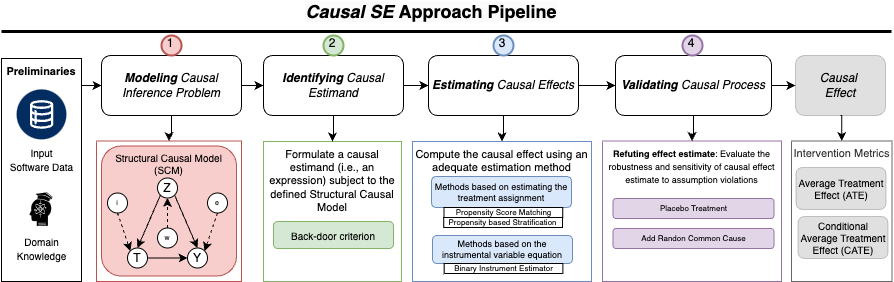

Loading the requred libraries. We are using huggingface libraries to download our datasets for softwre Engineering

In [17]:
from datasets import load_dataset
import pandas as pd
import seaborn as sns

The dataset includes three treatment dataset $t\in T$.

- Control template: "Complete the following python method: ```{Random_cut code}```",
- Treatment 1 (T1): "Write a Python method that starts with ```{Function Name}``` , I need to complete this function. Remove comments, summary and descriptions.",
- Treatment 2 (T2): "Remeber you have a Python function named ```{Method Signature}```, the function starts with the following code ```{Random_cut code}```. The description for the function is: ```{docstring}``` remove comments; remove summary; remove description; Return only the code"

In [13]:
dataset = "semeru/causal-se"
data_files="treatments.parquet"

dataset = load_dataset(dataset, cache_dir="../../datax", 
                       revision="main", 
                       data_files=data_files
                       )

dataset.set_format(type='pandas')

# We are using training set configure from Huggingface
treatments_df = dataset['train'][:]
print(treatments_df.shape)
treatments_df.head()


(8769, 35)


,commit_id,code,repo,documentation,id,w_n_ast_errors,w_ast_errors,w_vocab_size,d_id,commit_message,...,e_n_words,prediction,e_vocab_size,i_n_whitespaces,i_n_words,template,i_vocab_size,binary_treatment,treatment,y_po_lev
0,f65417656ba8c59438d832b6e2a431f78d40c21c,"def rolling(self, *args, **kwargs) -> RollingG...",pandas,{'docstring': ' Return a rolling group...,167770,0,,17,40113,TYP: more return annotations in core/ (#47618)...,...,72,Certainly! Here's the completed code:\n\n```py...,53,29,16,Complete the following python method: ```{}```,16,False,control,364
1,2a05ccdb07cff88e56661dee8a9271859354027f,"def expected_degree_graph(w, seed=None, selflo...",networkx,{'docstring': 'Returns a random graph with giv...,176730,0,,97,42064,Remove redundant py2 numeric conversions (#566...,...,332,Here is the completed python method:\n\n```pyt...,182,380,175,Complete the following python method: ```{}```,100,False,control,926
2,4c58179509e6f6047789efb0a95c2b0e20cb6c8f,"def save(self, path):\n \n os.ma...",mlflow,{'docstring': 'Write the evaluation results to...,19151,0,,36,2897,Improve evaluation api (#5256)\n\n* init\r\n\r...,...,1,exist_ok=True),1,23,9,Complete the following python method: ```{}```,9,False,control,771
3,3255fa4ebb9fbc1df6bb063c0eb77a0298ca8f72,def test_build_group_generic_issue_attachment(...,sentry,{'docstring': 'Test that a generic issue type'...,89933,0,,38,18592,feat(integrations): Support generic issue type...,...,1,"""danger""",1,152,50,Complete the following python method: ```{}```,38,False,control,835
4,b3bc4e734528d3b186c3a38a6e73e106c3555cc7,"def apply(self, func, mask=None) -> 'ImageProc...",DeepFaceLive,{'docstring': ' apply your own functio...,179114,0,,34,42906,ImageProcessor.py refactoring,...,32,```\n mask = mask.astype(bool)\n ...,28,86,38,Complete the following python method: ```{}```,34,False,control,302


In [14]:
documentation_df = pd.concat([treatments_df['id'], treatments_df['code'], treatments_df['documentation'].apply(pd.Series)], axis=1)
print(documentation_df.shape)
documentation_df.sample(5)


(8769, 7)


,id,code,docstring,language,n_whitespaces,n_words,vocab_size
7057,81164,def get_delayed_update_fields(self):\n ...,Return finalized dict of all fields that shoul...,en,15,16,16
7861,98450,"def parse_semver(version, operator) -> Optiona...",\n Attempts to parse a release version usin...,en,91,55,39
2164,186624,def parsed_paths(self) -> List[str]:\n ...,\n Returns a list of file paths that ha...,en,93,50,35
4896,260218,"def coverage_error(y_true, y_score, *, sample_...",Coverage error measure.\n\n Compute how far...,en,297,179,144
7380,205284,"def _create_project_state(self, with_applied_m...",\n Create a project state including all...,en,37,15,14


## Levenshtein normalization

In [15]:
column_to_normalize = 'y_po_lev'

min_value = treatments_df[column_to_normalize].values.min()
max_value = treatments_df[column_to_normalize].values.max()

treatments_df['y_po_lev_norm'] = (treatments_df[column_to_normalize] - min_value) / (max_value - min_value)

treatments_df.sample(5)

,commit_id,code,repo,documentation,id,w_n_ast_errors,w_ast_errors,w_vocab_size,d_id,commit_message,...,prediction,e_vocab_size,i_n_whitespaces,i_n_words,template,i_vocab_size,binary_treatment,treatment,y_po_lev,y_po_lev_norm
5633,d10f15e55806c6944827d801cd9c2d53f5da4186,def test_standard_get_document_model(self):\n ...,wagtail,{'docstring': 'Test get_document_model with no...,74848,0,,10,16326,Reformat with black,...,This method tests that the `get_document_model...,56,57,30,Write a Python method that starts with ```{}``...,30,True,T1,607,0.049305
8484,7fd72d9ee1e8847717195859bf6d608268a94e2f,"def get_next_stock_market_days(last_stock_day,...",OpenBBTerminal,{'docstring': 'Gets the next stock market day....,285879,0,,52,85472,Forecasting Menu [Work in Progress] (#1933)\n\...,...,"```python\nfrom datetime import datetime, time...",40,107,71,"Remeber you have a Python function named {}, t...",55,True,T2,591,0.048006
6874,cda8dfe6f45dc5ed394c2f5cda706cd6c729f713,def igcd(*args):\n \n if len(args) < 2:\...,sympy,{'docstring': 'Computes nonnegative integer gr...,195852,0,,46,47439,Improved documentation formatting,...,Certainly! Here's the final code for the `igcd...,55,193,112,"Remeber you have a Python function named {}, t...",94,True,T2,342,0.027780
7364,9c19aff7c7561e3a82978a272ecdaad40dda5c00,def get_current_site(request):\n \n # Im...,django,{'docstring': ' Check if contrib.sites is ...,204336,0,,29,50700,Refs #33476 -- Reformatted code with Black.,...,```python\ndef get_current_site(request):\n ...,36,100,78,"Remeber you have a Python function named {}, t...",59,True,T2,249,0.020226
49,65be461082dda54c8748922f9c29a19af1279fe1,"def decrement_part_small(self, part, ub):\n ...",sympy,{'docstring': 'Decrements part (a subrange of ...,197371,0,,114,48514,Remove abbreviations in documentation,...,"```python\ndef decrement_part_small(self, part...",168,188,74,Complete the following python method: ```{}```,56,False,control,1169,0.094956


### Types of variables used for building the causal graph

Potential outcomes:

Potential outcomes $Y^t$: Levenshtaien distance (code predicion, groundtruth), $t\in T$

Common causes are the code snippet grountruth metrics 
- w_ast_levels 
- w_n_whitespaces
- w_complexity
- w_nloc
- w_token_counts
- w_n_ast_nodes

Common causes affect both treatments $T$ and potential outcomes $Y$

Instrumental variables: Are the Software Engineering input put prompt metrics

- i_p_n_words
- i_n_whitespaces
- i_vocab_size 

Effect modifiers: Are the software engineering potential outcome metrics
- e_p_n_words
- e_n_whitespaces
- e_vocab_size 

## Dataset analysis

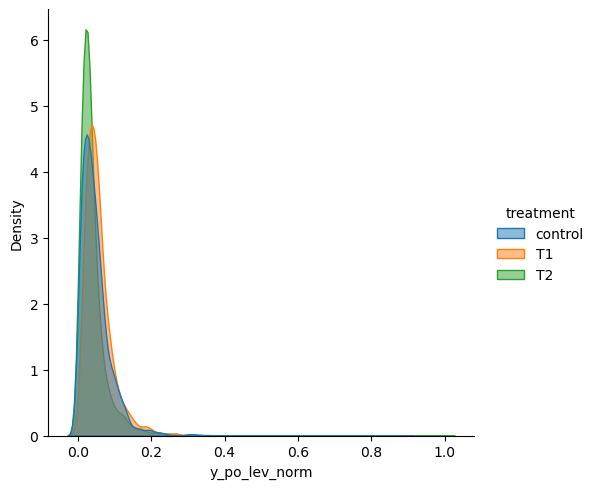

In [21]:
sns.displot(treatments_df, x="y_po_lev_norm", hue="treatment", kind="kde", fill=True, alpha=0.5)

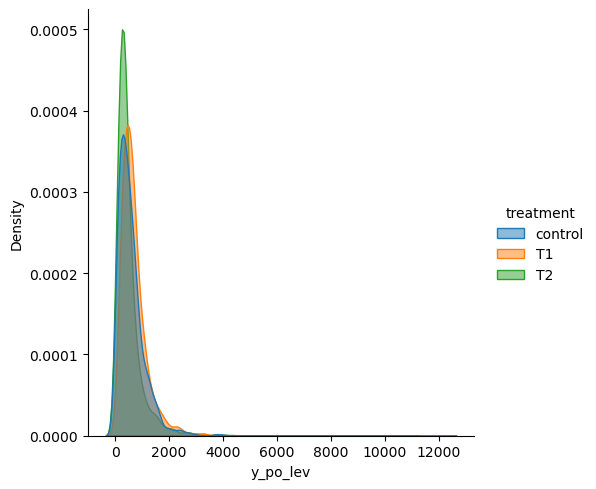

In [20]:
sns.displot(treatments_df, x="y_po_lev", hue="treatment", kind="kde", fill=True, alpha=0.5)


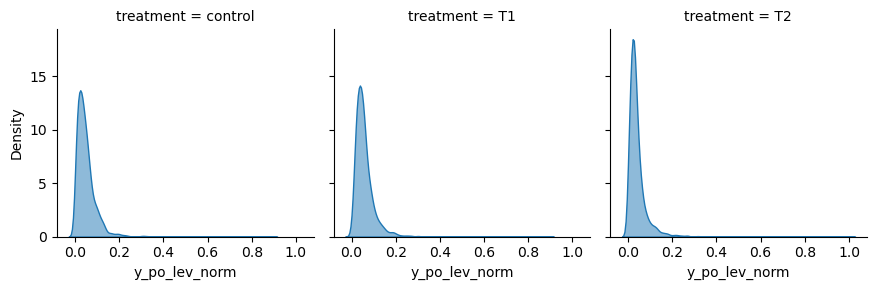

In [27]:
g = sns.FacetGrid(treatments_df, col="treatment", margin_titles=True)
g.map(sns.kdeplot, "y_po_lev_norm", fill=True, alpha=0.5)


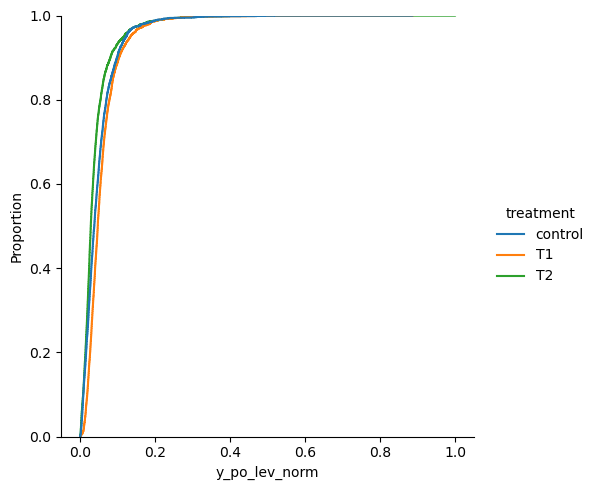

In [28]:
sns.displot(treatments_df, x="y_po_lev_norm", hue="treatment", kind="ecdf")

<Axes: xlabel='treatment', ylabel='y_po_lev_norm'>

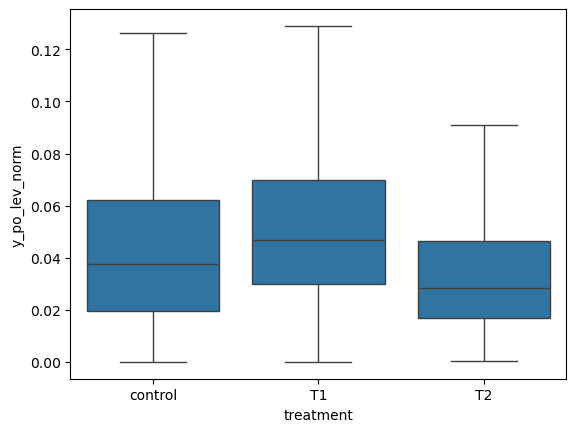

In [29]:
sns.boxplot(data=treatments_df[['y_po_lev_norm','treatment']], x="treatment", y="y_po_lev_norm",showfliers=False)


In [30]:
treatments_df[['y_po_lev','treatment']].groupby('treatment').describe()

y_po_lev                                                           
             count        mean         std  min    25%    50%    75%      max
treatment                                                                    
T1          2923.0  703.023948  581.868063  0.0  369.5  577.0  857.5  10919.0
T2          2923.0  490.223401  556.738150  4.0  205.5  349.0  571.5  12311.0
control     2923.0  591.967157  574.681895  0.0  243.0  464.0  767.5  10913.0

In [31]:
treatments_df[['y_po_lev','binary_treatment']].groupby('binary_treatment').describe()

y_po_lev                                                    \
                    count        mean         std  min    25%    50%    75%   
binary_treatment                                                              
False              2923.0  591.967157  574.681895  0.0  243.0  464.0  767.5   
True               5846.0  596.623674  579.250708  0.0  272.0  456.0  740.0   

                           
                      max  
binary_treatment           
False             10913.0  
True              12311.0

Explain metric granularity, in this case we are using sample granularity. CodeBLEU is a dataset level.

The more input prompt size is close to the GT, the less distance outcome, gt

We expect the following behavior in continues treatments: The more difference lev difference between prompts (i.e. control vs T1, T1 vs T2), the less difference at the potential outcome. We expect a negative correlations or causal effect

In [11]:
import numpy as np

from dowhy import CausalModel
import dowhy.datasets

### Variable description

## Comparing Treatment 1 Vs. Control

In [44]:
treatment1 = treatments_df[(treatments_df["treatment"]=="control") | (treatments_df["treatment"]=="T1") ].copy()

## Basic comon causes model for Treatment 1

### Step-1 Causal graph modeling

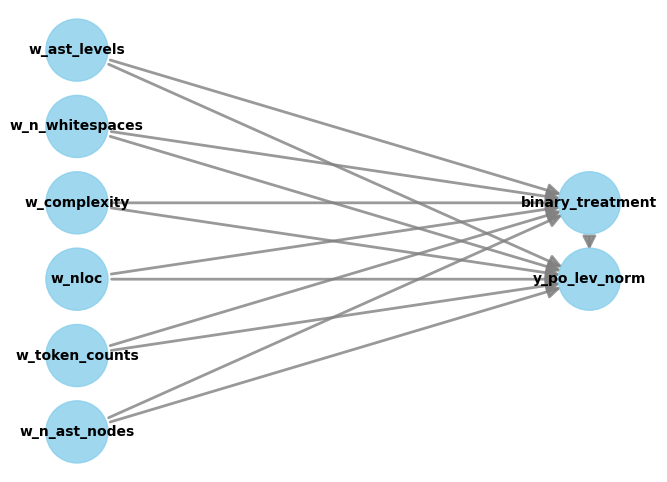

In [52]:
m1 = CausalModel(
        data = treatment1,
        treatment = ['binary_treatment'],
        outcome = ['y_po_lev_norm'],
        common_causes = ['w_ast_levels','w_n_whitespaces','w_complexity','w_nloc','w_token_counts','w_n_ast_nodes']
        #instruments = ['i_vocab_size']
        #graph= "diagram.dot"
        #common_causes= ['z_nloc']
    )
m1.view_model()

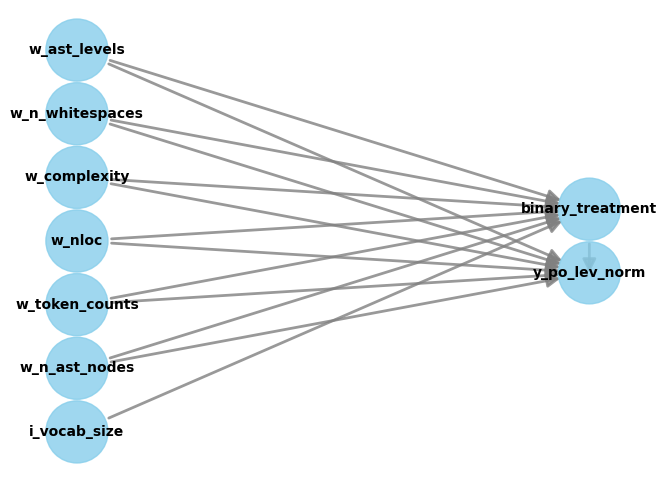

In [53]:
m2 = CausalModel(
        data = treatment1,
        treatment = ['binary_treatment'],
        outcome = ['y_po_lev_norm'],
        common_causes = ['w_ast_levels','w_n_whitespaces','w_complexity','w_nloc','w_token_counts','w_n_ast_nodes'],
        instruments = ['i_vocab_size']
        #graph= "diagram.dot"
        #common_causes= ['z_nloc']
    )
m2.view_model()

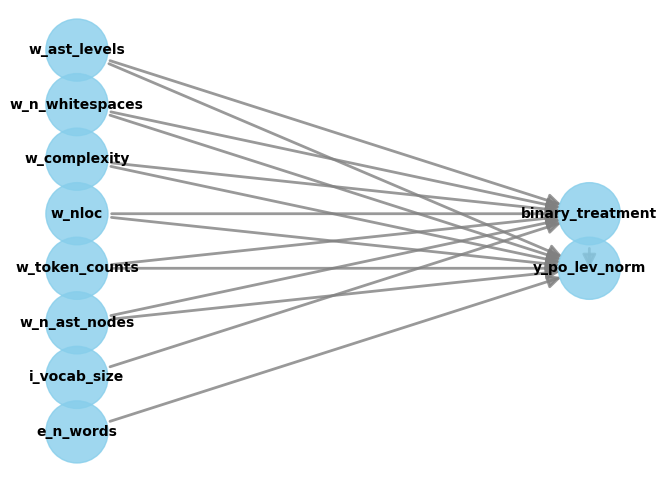

In [56]:
m3 = CausalModel(
        data = treatment1,
        treatment = ['binary_treatment'],
        outcome = ['y_po_lev_norm'],
        common_causes = ['w_ast_levels','w_n_whitespaces','w_complexity','w_nloc','w_token_counts','w_n_ast_nodes'],
        instruments = ['i_vocab_size'],
        effect_modifiers=['e_n_words']
        #graph= "diagram.dot"
        #common_causes= ['z_nloc']
    )
m3.view_model()

### Step-2 Identifiying Causal Estimand

In [54]:
identified_estimand_m1 = m1.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_m1)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
levels,w_token_counts,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [55]:
identified_estimand_m2 = m2.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_m2)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
levels,w_token_counts,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                  -1⎤
 ⎢       d                      ⎛       d                          ⎞  ⎥
E⎢───────────────(yₚₒ ₗ

In [57]:
identified_estimand_m3 = m3.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_m3)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
levels,w_token_counts,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                  -1⎤
 ⎢       d                      ⎛       d                          ⎞  ⎥
E⎢───────────────(yₚₒ ₗ

### Step-3 Causal effect estimation

In [60]:
estimate_m1_1 = m1.estimate_effect(identified_estimand_m1,
        method_name="backdoor.propensity_score_matching", test_significance=True)

print(estimate_m1_1)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
levels,w_token_counts,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity)

## Realized estimand
b: y_po_lev_norm~binary_treatment+w_n_ast_nodes+w_nloc+w_n_whitespaces+w_ast_levels+w_token_counts+w_complexity
Target units: ate

## Estimate
Mean value:

In [61]:
estimate_m1_2 = m1.estimate_effect(identified_estimand_m1,
        method_name="backdoor.propensity_score_stratification", test_significance=True)

print(estimate_m1_2)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
levels,w_token_counts,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity)

## Realized estimand
b: y_po_lev_norm~binary_treatment+w_n_ast_nodes+w_nloc+w_n_whitespaces+w_ast_levels+w_token_counts+w_complexity
Target units: ate

## Estimate
Mean value:

In [62]:
estimate_m1_3 = m1.estimate_effect(identified_estimand_m1,
        method_name="backdoor.propensity_score_weighting", test_significance=True)

print(estimate_m1_3)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
levels,w_token_counts,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_n_ast_nodes,w_nloc,w_n_whitespaces,w_ast_levels,w_token_counts,w_complexity)

## Realized estimand
b: y_po_lev_norm~binary_treatment+w_n_ast_nodes+w_nloc+w_n_whitespaces+w_ast_levels+w_token_counts+w_complexity
Target units: ate

## Estimate
Mean value:

In [59]:
estimate_m2 = m2.estimate_effect(identified_estimand_m2,
        method_name="iv.instrumental_variable", test_significance=True)

print(estimate_m2)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: iv
Estimand expression:
 ⎡                                                                  -1⎤
 ⎢       d                      ⎛       d                          ⎞  ⎥
E⎢───────────────(yₚₒ ₗₑᵥ ₙₒᵣₘ)⋅⎜───────────────([binaryₜᵣₑₐₜₘₑₙₜ])⎟  ⎥
 ⎣d[i_vocab_size]               ⎝d[i_vocab_size]                   ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y_po_lev_norm then ¬(U →→{i_vocab_size})
Estimand assumption 2, Exclusion: If we remove {i_vocab_size}→{binary_treatment}, then ¬({i_vocab_size}→y_po_lev_norm)

## Realized estimand
Realized estimand: Wald Estimator
Realized estimand type: EstimandType.NONPARAMETRIC_ATE
Estimand expression:
 ⎡      d                    ⎤  -1⎡      d                       ⎤
E⎢─────────────(yₚₒ ₗₑᵥ ₙₒᵣₘ)⎥⋅E  ⎢─────────────(binaryₜᵣₑₐₜₘₑₙₜ)⎥
 ⎣di_vocab_size              ⎦    ⎣di_vocab_size                 ⎦
Estimand assumption 1, As

### Step-4 Validation

In [72]:
validaton_placebo_cause_m1_1 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_1,
                method_name="placebo_treatment_refuter",
                placebo_type="permute"
        )
print(validaton_placebo_cause_m1_1)

Refute: Use a Placebo Treatment
Estimated effect:0.00845003618585755
New effect:0.001495977510440241
p value:0.8



In [71]:
validaton_random_cause_m1_1 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_1,
                method_name="random_common_cause",
                placebo_type="permute"
        )
print(validaton_random_cause_m1_1)

Refute: Add a random common cause
Estimated effect:0.00845003618585755
New effect:0.00845003618585755
p value:1.0



In [73]:
validaton_placebo_cause_m1_2 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_2,
                method_name="placebo_treatment_refuter",
                placebo_type="permute"
        )
print(validaton_placebo_cause_m1_2)

Refute: Use a Placebo Treatment
Estimated effect:0.009020939888569841
New effect:-0.00010959994973468591
p value:0.88



In [74]:
validaton_random_cause_m1_2 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_2,
                method_name="random_common_cause",
                placebo_type="permute"
        )
print(validaton_random_cause_m1_1)

Refute: Add a random common cause
Estimated effect:0.00845003618585755
New effect:0.00845003618585755
p value:1.0



In [75]:
validaton_placebo_cause_m1_3 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_3,
                method_name="placebo_treatment_refuter",
                placebo_type="permute"
        )
print(validaton_placebo_cause_m1_2)

Refute: Use a Placebo Treatment
Estimated effect:0.009020939888569841
New effect:-0.00010959994973468591
p value:0.88



In [76]:
validaton_random_cause_m1_3 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_3,
                method_name="random_common_cause",
                placebo_type="permute"
        )
print(validaton_random_cause_m1_3)

Refute: Add a random common cause
Estimated effect:0.009020939888569827
New effect:0.009020939888569827
p value:1.0



In [77]:
validaton_placebo_cause_m2 = m2.refute_estimate(
                identified_estimand_m2,
                estimate_m2,
                method_name="placebo_treatment_refuter",
                placebo_type="permute"
        )
print(validaton_placebo_cause_m2)

Refute: Use a Placebo Treatment
Estimated effect:0.13918999545981528
New effect:0.001085531385959097
p value:0.7



In [78]:
validaton_random_cause_m2 = m2.refute_estimate(
                identified_estimand_m2,
                estimate_m2,
                method_name="random_common_cause",
                placebo_type="permute"
        )
print(validaton_random_cause_m2)

Refute: Add a random common cause
Estimated effect:0.13918999545981528
New effect:0.1391899954598153
p value:1.0



## Comparing Treatment 2 Vs. Control

### Preliminaries, treatment software dataset

In [26]:
treatment2 = treatments_df[(treatments_df["treatment"]=="control") | (treatments_df["treatment"]=="T2") ].copy()

## Common causes model for treatment 2

### Step-2 Causal graph modeling

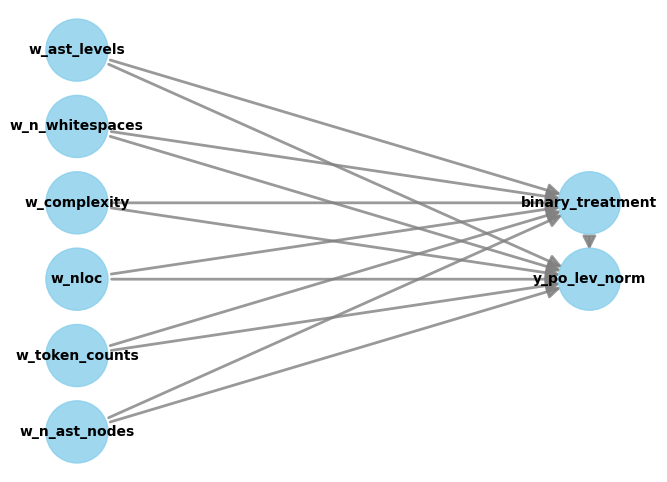

In [27]:
m1 = CausalModel(
        data = treatment2,
        treatment = ['binary_treatment'],
        outcome = ['y_po_lev_norm'],
        common_causes = ['w_ast_levels','w_n_whitespaces','w_complexity','w_nloc','w_token_counts','w_n_ast_nodes']
    )
m1.view_model()

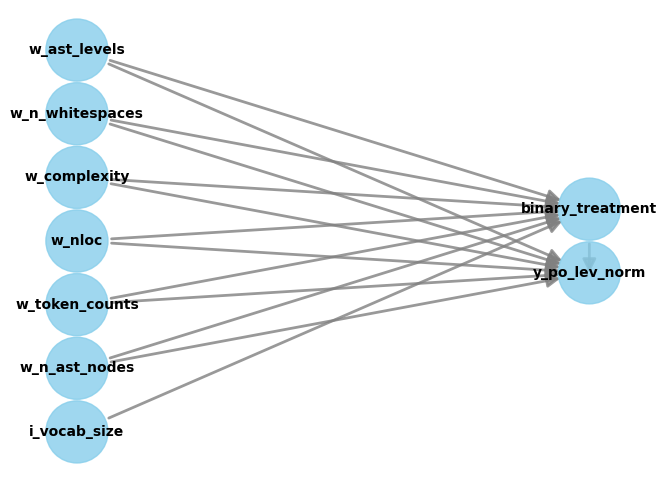

In [28]:
m2 = CausalModel(
        data = treatment2,
        treatment = ['binary_treatment'],
        outcome = ['y_po_lev_norm'],
        common_causes = ['w_ast_levels','w_n_whitespaces','w_complexity','w_nloc','w_token_counts','w_n_ast_nodes'],
        instruments = ['i_vocab_size']
        #graph= "diagram.dot"
        #common_causes= ['z_nloc']
    )
m2.view_model()

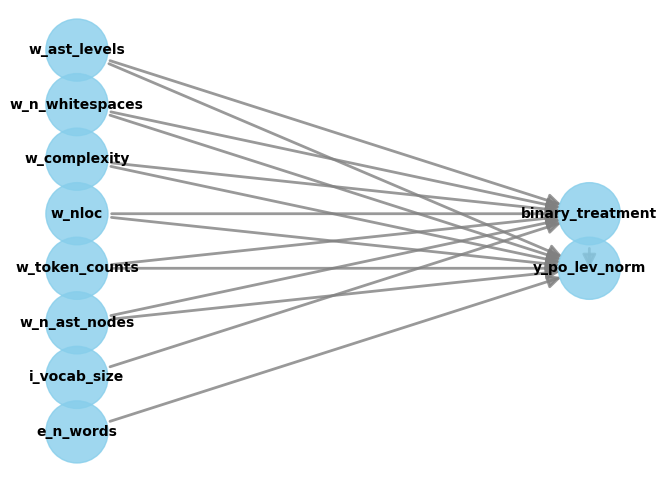

In [29]:
m3 = CausalModel(
        data = treatment2,
        treatment = ['binary_treatment'],
        outcome = ['y_po_lev_norm'],
        common_causes = ['w_ast_levels','w_n_whitespaces','w_complexity','w_nloc','w_token_counts','w_n_ast_nodes'],
        instruments = ['i_vocab_size'],
        effect_modifiers=['e_n_words']
        #graph= "diagram.dot"
        #common_causes= ['z_nloc']
    )
m3.view_model()

### Step-2 Identifiying Causal Estimand

In [30]:
identified_estimand_m1 = m1.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_m1)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_token_counts,w_ast_levels,w_nloc,w_n_whit
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
espaces,w_n_ast_nodes,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_token_counts,w_ast_levels,w_nloc,w_n_whitespaces,w_n_ast_nodes,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_token_counts,w_ast_levels,w_nloc,w_n_whitespaces,w_n_ast_nodes,w_complexity)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [31]:
identified_estimand_m2 = m2.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_m2)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_token_counts,w_nloc,w_ast_levels,w_n_whit
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
espaces,w_n_ast_nodes,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_token_counts,w_nloc,w_ast_levels,w_n_whitespaces,w_n_ast_nodes,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_token_counts,w_nloc,w_ast_levels,w_n_whitespaces,w_n_ast_nodes,w_complexity)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                  -1⎤
 ⎢       d                      ⎛       d                          ⎞  ⎥
E⎢───────────────(yₚₒ ₗ

In [32]:
identified_estimand_m3 = m3.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_m3)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_token_counts,w_nloc,w_ast_levels,w_n_whit
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
espaces,w_n_ast_nodes,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_token_counts,w_nloc,w_ast_levels,w_n_whitespaces,w_n_ast_nodes,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_token_counts,w_nloc,w_ast_levels,w_n_whitespaces,w_n_ast_nodes,w_complexity)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                  -1⎤
 ⎢       d                      ⎛       d                          ⎞  ⎥
E⎢───────────────(yₚₒ ₗ

### Step-3 Causal effect estimation

In [33]:
estimate_m1_1 = m1.estimate_effect(identified_estimand_m1,
        method_name="backdoor.propensity_score_matching", test_significance=True)

print(estimate_m1_1)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_token_counts,w_ast_levels,w_nloc,w_n_whit
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
espaces,w_n_ast_nodes,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_token_counts,w_ast_levels,w_nloc,w_n_whitespaces,w_n_ast_nodes,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_token_counts,w_ast_levels,w_nloc,w_n_whitespaces,w_n_ast_nodes,w_complexity)

## Realized estimand
b: y_po_lev_norm~binary_treatment+w_token_counts+w_ast_levels+w_nloc+w_n_whitespaces+w_n_ast_nodes+w_complexity
Target units: ate

## Estimate
Mean value:

In [34]:
estimate_m1_2 = m1.estimate_effect(identified_estimand_m1,
        method_name="backdoor.propensity_score_stratification", test_significance=True)

print(estimate_m1_2)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_token_counts,w_ast_levels,w_nloc,w_n_whit
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
espaces,w_n_ast_nodes,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_token_counts,w_ast_levels,w_nloc,w_n_whitespaces,w_n_ast_nodes,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_token_counts,w_ast_levels,w_nloc,w_n_whitespaces,w_n_ast_nodes,w_complexity)

## Realized estimand
b: y_po_lev_norm~binary_treatment+w_token_counts+w_ast_levels+w_nloc+w_n_whitespaces+w_n_ast_nodes+w_complexity
Target units: ate

## Estimate
Mean value:

In [35]:
estimate_m1_3 = m1.estimate_effect(identified_estimand_m1,
        method_name="backdoor.propensity_score_weighting", test_significance=True)

print(estimate_m1_3)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                     
──────────────────(E[y_po_lev_norm|w_token_counts,w_ast_levels,w_nloc,w_n_whit
d[binaryₜᵣₑₐₜₘₑₙₜ]                                                            

                                    
espaces,w_n_ast_nodes,w_complexity])
                                    
Estimand assumption 1, Unconfoundedness: If U→{binary_treatment} and U→y_po_lev_norm then P(y_po_lev_norm|binary_treatment,w_token_counts,w_ast_levels,w_nloc,w_n_whitespaces,w_n_ast_nodes,w_complexity,U) = P(y_po_lev_norm|binary_treatment,w_token_counts,w_ast_levels,w_nloc,w_n_whitespaces,w_n_ast_nodes,w_complexity)

## Realized estimand
b: y_po_lev_norm~binary_treatment+w_token_counts+w_ast_levels+w_nloc+w_n_whitespaces+w_n_ast_nodes+w_complexity
Target units: ate

## Estimate
Mean value:

In [36]:
estimate_m2 = m2.estimate_effect(identified_estimand_m2,
        method_name="iv.instrumental_variable", test_significance=True)

print(estimate_m2)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: iv
Estimand expression:
 ⎡                                                                  -1⎤
 ⎢       d                      ⎛       d                          ⎞  ⎥
E⎢───────────────(yₚₒ ₗₑᵥ ₙₒᵣₘ)⋅⎜───────────────([binaryₜᵣₑₐₜₘₑₙₜ])⎟  ⎥
 ⎣d[i_vocab_size]               ⎝d[i_vocab_size]                   ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y_po_lev_norm then ¬(U →→{i_vocab_size})
Estimand assumption 2, Exclusion: If we remove {i_vocab_size}→{binary_treatment}, then ¬({i_vocab_size}→y_po_lev_norm)

## Realized estimand
Realized estimand: Wald Estimator
Realized estimand type: EstimandType.NONPARAMETRIC_ATE
Estimand expression:
 ⎡      d                    ⎤  -1⎡      d                       ⎤
E⎢─────────────(yₚₒ ₗₑᵥ ₙₒᵣₘ)⎥⋅E  ⎢─────────────(binaryₜᵣₑₐₜₘₑₙₜ)⎥
 ⎣di_vocab_size              ⎦    ⎣di_vocab_size                 ⎦
Estimand assumption 1, As

### Step-4 Validation

In [37]:
validaton_placebo_cause_m1_1 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_1,
                method_name="placebo_treatment_refuter",
                placebo_type="permute"
        )
print(validaton_placebo_cause_m1_1)

Refute: Use a Placebo Treatment
Estimated effect:-0.02553585234402738
New effect:-0.0017070664033758702
p value:0.96



In [38]:
validaton_random_cause_m1_1 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_1,
                method_name="random_common_cause",
                placebo_type="permute"
        )
print(validaton_random_cause_m1_1)

Refute: Add a random common cause
Estimated effect:-0.02553585234402738
New effect:-0.025535852344027384
p value:1.0



In [39]:
validaton_placebo_cause_m1_2 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_2,
                method_name="placebo_treatment_refuter",
                placebo_type="permute"
        )
print(validaton_placebo_cause_m1_2)

Refute: Use a Placebo Treatment
Estimated effect:-0.008264459135297088
New effect:9.020078419781696e-05
p value:0.8400000000000001



In [40]:
validaton_random_cause_m1_2 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_2,
                method_name="random_common_cause",
                placebo_type="permute"
        )
print(validaton_random_cause_m1_1)

Refute: Add a random common cause
Estimated effect:-0.02553585234402738
New effect:-0.025535852344027384
p value:1.0



In [41]:
validaton_placebo_cause_m1_3 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_3,
                method_name="placebo_treatment_refuter",
                placebo_type="permute"
        )
print(validaton_placebo_cause_m1_2)

Refute: Use a Placebo Treatment
Estimated effect:-0.008264459135297088
New effect:9.020078419781696e-05
p value:0.8400000000000001



In [42]:
validaton_random_cause_m1_3 = m1.refute_estimate(
                identified_estimand_m1,
                estimate_m1_3,
                method_name="random_common_cause",
                placebo_type="permute"
        )
print(validaton_random_cause_m1_3)

Refute: Add a random common cause
Estimated effect:-0.008264459135297102
New effect:-0.008264459135297102
p value:1.0



In [43]:
validaton_placebo_cause_m2 = m2.refute_estimate(
                identified_estimand_m2,
                estimate_m2,
                method_name="placebo_treatment_refuter",
                placebo_type="permute"
        )
print(validaton_placebo_cause_m2)

AttributeError: 'float' object has no attribute 'shape'

In [ ]:
validaton_random_cause_m2 = m2.refute_estimate(
                identified_estimand_m2,
                estimate_m2,
                method_name="random_common_cause",
                placebo_type="permute"
        )
print(validaton_random_cause_m2)

### Brainstorming ideas

Developer experience,
Demographic info
machine generated? 
Is a code debug?

- [] dependent and independent cofounders
- [ ] compute cofounders correlation

- Model parameters
- Loss prediction
- Sampling
